# Section 3: Cloud Root Analysis

**3.1a** Vertical profiles of domain-mean resolved turbulent fluxes (w'θ_l', w'q_t') — 2stream vs raytracer  
**3.1b** Surface fluxes (H, LE) conditioned on cloud-root vs. unshaded columns  
**3.2**  Cloud-root cross-sections in non-dimensionalised coordinates (z/z_sl, x/L)

> **Section 3.2 requires 3D data.** From the run directory, run:
> ```
> cd $RUN_DIR
> python $MICROHH/python/3d_to_nc.py -v thl qt ql w b
> ```
> then set `HAS_3D = True` below.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
from cass_analysis import (
    RunSet,
    load_stats_ensemble,
    load_xy_files, load_xy_ensemble,
    conditioned_means_ensemble,
    load_3d_nc,
    compute_z_sl,
    cloud_mask_2d, find_cloud_objects,
    extract_root_slice, nondim_slice,
    extract_cloud_root_profiles_1d,
    compute_normalized_cloud_root_profiles,
    plot_flux_profiles, plot_flux_conditioned, plot_cloud_root_slice,
    plot_cloud_root_profiles_comparison, plot_normalized_cloud_root_profiles,
    RT_STYLE, RT_LABEL,
    rho, cp, Lv,
)

# ── CONFIGURATION ─────────────────────────────────────────────────────────────
SCRATCH = "/pscratch/sd/m/mpowell/CASS_LES"
EXPT    = "debug/no_aerosols"      # change to switch experiment
N_REPS  = 1                 # 1 for debug, 4 for production
HAS_3D  = True             # set True after running 3d_to_nc.py
# ─────────────────────────────────────────────────────────────────────────────

rs = RunSet(EXPT, f"{SCRATCH}/{EXPT}", n_reps=N_REPS)
print(rs)

RunSet('debug/no_aerosols', root=/pscratch/sd/m/mpowell/CASS_LES/debug/no_aerosols)
  2stream: 1 rep(s)
  raytracer: 1 rep(s)


In [2]:
# Load stats for both RT types
s2s_mean, s2s_std = load_stats_ensemble(rs.dirs["2stream"])
srt_mean, srt_std = load_stats_ensemble(rs.dirs["raytracer"])

# Estimate z_sl at the end of the simulation (mature cloud period)
z_sl_2s = compute_z_sl(s2s_mean, time_idx=-1)
z_sl_rt = compute_z_sl(srt_mean, time_idx=-1)
print(f"z_sl (2stream):   {z_sl_2s:.0f} m")
print(f"z_sl (raytracer): {z_sl_rt:.0f} m")

z_sl (2stream):   1612 m
z_sl (raytracer): 1638 m


## 3.1  Cloud-root vertical cross-sections

Vertical slices of turbulent fluxes (w'θ_l', w'q_t') through the largest cloud root object
at a selected dump time, non-dimensionalised by L (cloud-root width along slice) and z_sl.

**Cloud root definition used here**: column where LWP > 0 (`qlqi_path > 0`); L = width of the LWP > 0 region along the slice.

Requires 3D data: set `HAS_3D = True` in the configuration cell and run `3d_to_nc.py` first.

In [4]:
if not HAS_3D:
    print("HAS_3D = False — skipping Section 3.2.")
    print("To enable: run 3d_to_nc.py in both RT run dirs, then set HAS_3D = True.")
else:
    # ── Load 3D data for both RT types (first rep each) ───────────────────────
    rep_dirs_3d = {rt: rs.dirs[rt][0] for rt in ("2stream", "raytracer")}
    ds_3d_dict  = {}
    for rt, rep_dir in rep_dirs_3d.items():
        ds_3d_dict[rt] = load_3d_nc(rep_dir, variables=["thl", "qt", "ql", "w"])
        print(f"{rt} dump times: {[str(t)[:16] for t in ds_3d_dict[rt].time.values]}")

2stream dump times: ['2005-07-24T05:30', '2005-07-24T06:30', '2005-07-24T07:30', '2005-07-24T08:30', '2005-07-24T09:30', '2005-07-24T10:30', '2005-07-24T11:30', '2005-07-24T12:30', '2005-07-24T13:30', '2005-07-24T14:30', '2005-07-24T15:30', '2005-07-24T16:30', '2005-07-24T17:30', '2005-07-24T18:30']
raytracer dump times: ['2005-07-24T05:30', '2005-07-24T06:30', '2005-07-24T07:30', '2005-07-24T08:30', '2005-07-24T09:30', '2005-07-24T10:30', '2005-07-24T11:30', '2005-07-24T12:30', '2005-07-24T13:30', '2005-07-24T14:30', '2005-07-24T15:30', '2005-07-24T16:30', '2005-07-24T17:30']


In [5]:
if HAS_3D:
    DUMP_TIME_IDX = -1   # change to inspect other dump times

    _stats = {"2stream": s2s_mean, "raytracer": srt_mean}
    results_3d = {}

    for rt, rep_dir in rep_dirs_3d.items():
        ds      = ds_3d_dict[rt]
        ds_t    = ds.isel(time=DUMP_TIME_IDX).load()
        dtime   = ds.time.values[DUMP_TIME_IDX]

        # Cloud mask from xy LWP at closest xy timestep
        ds_xy   = load_xy_files(rep_dir, variables=["qlqi_path"])
        dt_arr  = np.abs(ds_xy.time.values.astype("datetime64[ns]").astype(float)
                         - np.datetime64(dtime, "ns").astype(float))
        xy_tidx = int(np.argmin(dt_arr))
        mask_2d = cloud_mask_2d(ds_xy["qlqi_path"].isel(time=xy_tidx).values)

        dx, dy  = float(ds_xy.x[1] - ds_xy.x[0]), float(ds_xy.y[1] - ds_xy.y[0])
        labeled, props = find_cloud_objects(mask_2d, dx, dy, min_L=2*dx)

        # z_sl at this dump time from stats
        sm      = _stats[rt]
        dt_st   = np.abs(sm["t_local"].values.astype("datetime64[ns]").astype(float)
                         - np.datetime64(dtime, "ns").astype(float))
        z_sl    = compute_z_sl(sm, time_idx=int(np.argmin(dt_st)))

        results_3d[rt] = dict(ds_t=ds_t, dump_time=dtime, ds_xy=ds_xy,
                              mask_2d=mask_2d, dx=dx, dy=dy,
                              labeled=labeled, props=props, z_sl=z_sl)
        print(f"{rt}: {len(props)} objects, cloud fraction {mask_2d.mean():.2%}, "
              f"z_sl={z_sl:.0f} m  [{str(dtime)[:16]}]")
        for p in props[:3]:
            print(f"  label={p['label']}  L={p['L']:.0f} m  area={p['area_m2']/1e6:.2f} km²  "
                  f"centroid=({p['cy']},{p['cx']})")

2stream: 8 objects, cloud fraction 8.25%, z_sl=1612 m  [2005-07-24T18:30]
  label=6  L=1065 m  area=0.89 km²  centroid=(54,17)
  label=7  L=910 m  area=0.65 km²  centroid=(60,34)
  label=4  L=806 m  area=0.51 km²  centroid=(31,35)
raytracer: 8 objects, cloud fraction 6.37%, z_sl=1638 m  [2005-07-24T17:30]
  label=10  L=1128 m  area=1.00 km²  centroid=(52,7)
  label=4  L=964 m  area=0.73 km²  centroid=(30,45)
  label=2  L=714 m  area=0.40 km²  centroid=(14,12)


In [6]:
if HAS_3D:
    OBJECT_IDX  = 0      # index into props list (sorted by size desc)
    ORIENTATION = "y"    # 'y' → xz-slice through centroid row

    slices_nd = {}

    for rt, res in results_3d.items():
        if len(res["props"]) == 0:
            print(f"{rt}: no cloud objects, skipping.")
            continue

        obj = res["props"][OBJECT_IDX]
        sl  = extract_root_slice(res["ds_t"], cy=obj["cy"], cx=obj["cx"],
                                 orientation=ORIENTATION)

        if ORIENTATION == "y":
            mask_1d      = (res["labeled"] == obj["label"])[obj["cy"], :]
            horiz_coords = res["ds_xy"].x.values
        else:
            mask_1d      = (res["labeled"] == obj["label"])[:, obj["cx"]]
            horiz_coords = res["ds_xy"].y.values

        sl_nd = nondim_slice(sl, mask_1d, horiz_coords, res["z_sl"])
        slices_nd[rt] = dict(sl_nd=sl_nd, mask_1d=mask_1d, obj=obj)
        print(f"{rt}: obj label={obj['label']}  L={sl_nd.attrs['L_m']:.0f} m  "
              f"z_sl={sl_nd.attrs['z_sl_m']:.0f} m")

2stream: obj label=6  L=1100 m  z_sl=1612 m
raytracer: obj label=10  L=1400 m  z_sl=1638 m


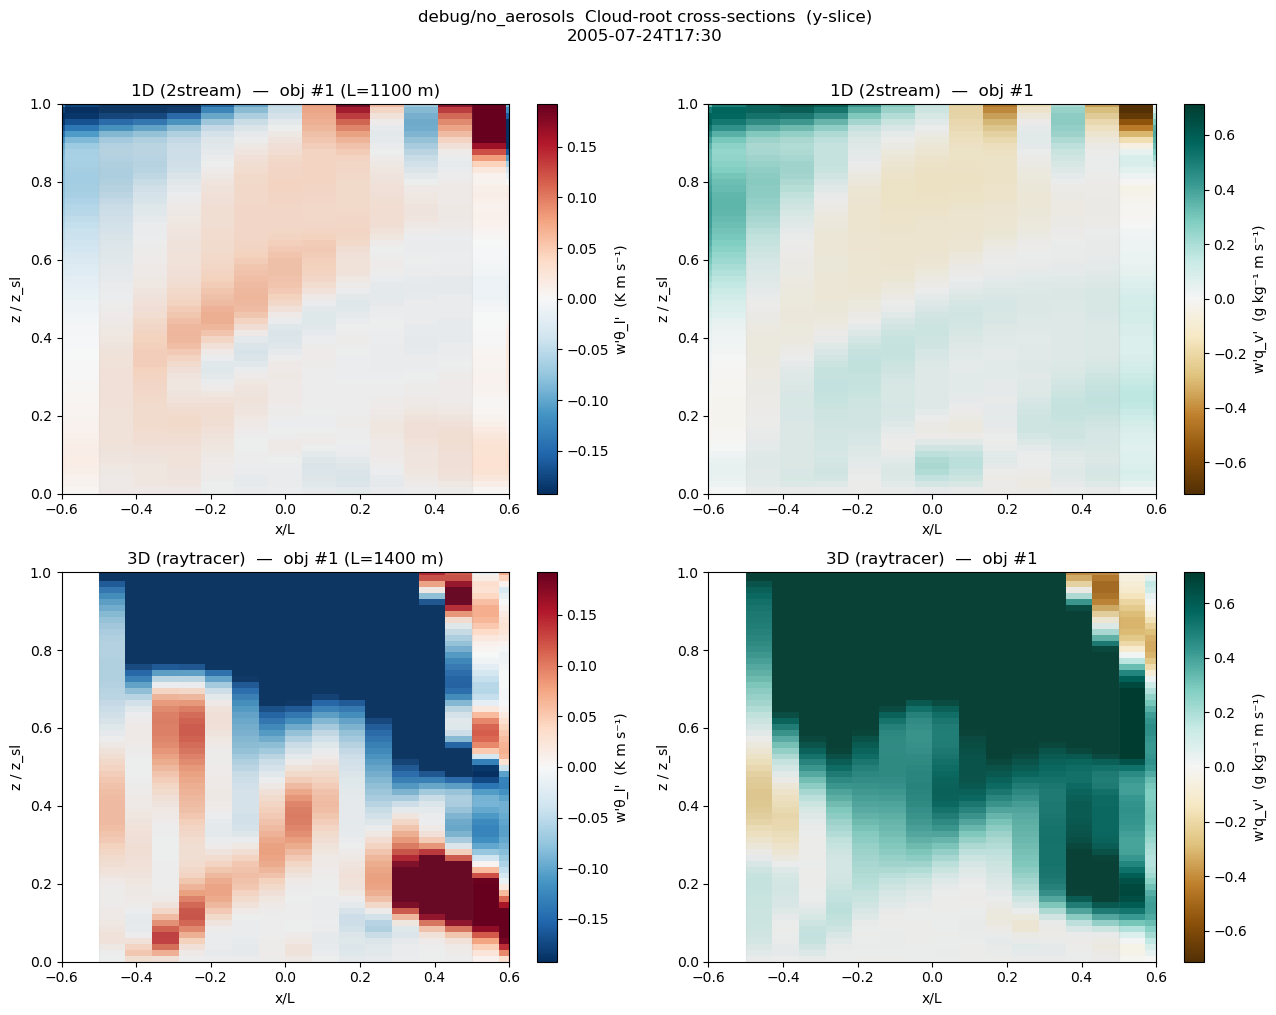

In [7]:
if HAS_3D and slices_nd:
    # ── Compute shared colorbar limits across both RT types ───────────────────
    def _flux_arrays(res, zmax_sl=1.0):
        sl  = res["sl_nd"]
        fthl = (sl["thl_prime"] * sl["w_prime"]).squeeze()
        fqv  = (sl["qv_prime"]  * sl["w_prime"]).squeeze() * 1e3
        zdim = "z" if "z" in fthl.dims else "zh"
        zm   = fthl[zdim].values <= zmax_sl
        return fthl.isel({zdim: zm}).values, fqv.isel({zdim: zm}).values

    all_thl = np.concatenate([_flux_arrays(res)[0].ravel() for res in slices_nd.values()])
    all_qv  = np.concatenate([_flux_arrays(res)[1].ravel() for res in slices_nd.values()])
    vmax_thl = float(np.nanpercentile(np.abs(all_thl), 95))
    vmax_qv  = float(np.nanpercentile(np.abs(all_qv),  95))
    shared_vlim_thl = (-vmax_thl, vmax_thl)
    shared_vlim_qv  = (-vmax_qv,  vmax_qv)

    # ── 2-row figure: top = 2stream, bottom = raytracer ───────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    for row, rt in enumerate(("2stream", "raytracer")):
        if rt not in slices_nd:
            axes[row, 0].set_visible(False)
            axes[row, 1].set_visible(False)
            continue
        res  = slices_nd[rt]
        ax_l, ax_r = axes[row]
        plot_cloud_root_slice(ax_l, ax_r, res["sl_nd"],
                              cloud_mask_1d=res["mask_1d"], zmax_sl=1.0,
                              vlim_thl=shared_vlim_thl, vlim_qv=shared_vlim_qv)
        ax_l.set_title(f"{RT_LABEL[rt]}  —  obj #{OBJECT_IDX+1} (L={res['sl_nd'].attrs['L_m']:.0f} m)")
        ax_r.set_title(f"{RT_LABEL[rt]}  —  obj #{OBJECT_IDX+1}")

    dump_time_str = str(results_3d["raytracer"]["dump_time"])[:16]
    plt.suptitle(
        f"{rs.name}  Cloud-root cross-sections  ({ORIENTATION}-slice)\n{dump_time_str}",
        y=1.01,
    )
    plt.tight_layout()
    plt.show()

## 3.2  Normalised cloud-root flux profiles  (2stream vs raytracer)

At each 3D dump time:
1. Compute w'θ_l' and w'q_v' averaged over cloud-root columns (LWP > 0)
2. Normalise by the domain-mean flux integrated over the full sub-cloud layer at that time:

$$\hat{F}_\text{cloud}(\zeta,\,t) = \frac{F_\text{cloud}(z,\,t)}{\displaystyle\int_0^{z_\text{sl}(t)} F_\text{domain}(z,\,t)\,\mathrm{d}z}$$

3. Non-dimensionalise height: $\zeta = z\,/\,z_\text{sl}(t)$ using that time step's $z_\text{sl}$
4. Interpolate onto a common $\zeta$ grid (0–1.5), **then** average across dump times

Step 4 ensures profiles are aligned in physical structure before averaging — a feature always at $0.3\,z_\text{sl}$ will not be smeared by $z_\text{sl}$ variability across dump times.

Plot shows time-mean ± 1 std, 2stream vs raytracer.

Computing normalised profiles for 2stream (14 dump times)...


/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cass_analysis.py:756: RuntimeWarning: divide by zero encountered in divide
  zeta_t = z / z_sl


  done  |  mean z_sl = 884 m  |  norm_thl range: -5.3179 – 50.8204  K m² s⁻¹
Computing normalised profiles for raytracer (13 dump times)...


/global/u2/m/mpowell/repos/microhh/cases/cass/analysis/cass_analysis.py:756: RuntimeWarning: divide by zero encountered in divide
  zeta_t = z / z_sl


  done  |  mean z_sl = 834 m  |  norm_thl range: 0.0000 – 53.7628  K m² s⁻¹


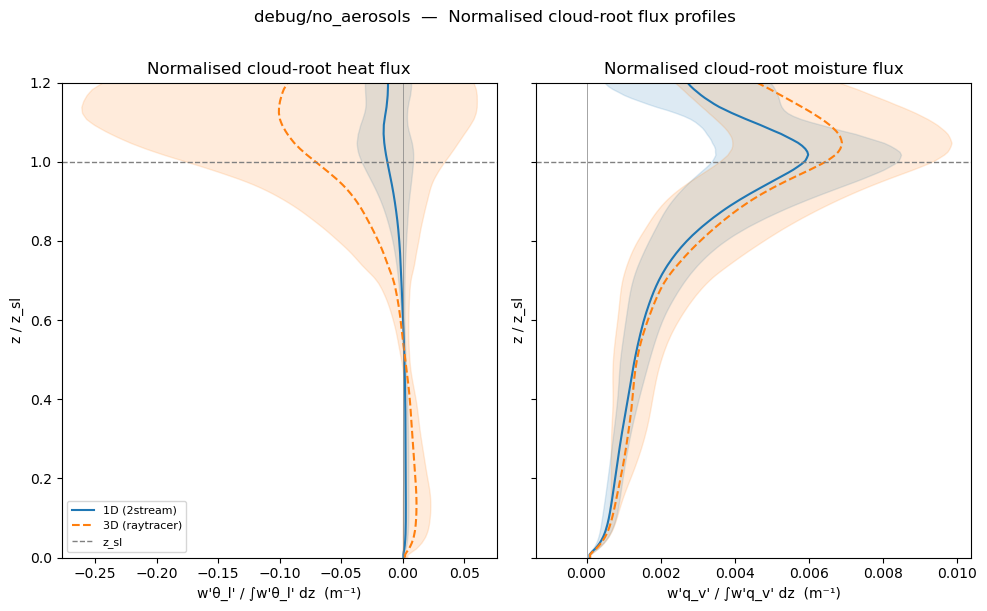

In [ ]:
if not HAS_3D:
    print("Skipping Section 3.2: set HAS_3D=True and run 3d_to_nc.py in both RT dirs.")
else:
    # Reuse ds_3d_dict and rep_dirs_3d from Section 3.2 if already loaded,
    # otherwise load here
    if "ds_3d_dict" not in dir():
        rep_dirs_3d = {rt: rs.dirs[rt][0] for rt in ("2stream", "raytracer")}
        ds_3d_dict  = {rt: load_3d_nc(rep_dirs_3d[rt], variables=["thl", "qt", "ql", "w"])
                       for rt in ("2stream", "raytracer")}

    _stats = {"2stream": s2s_mean, "raytracer": srt_mean}
    nd_results = {}

    for rt in ("2stream", "raytracer"):
        rep_dir = rep_dirs_3d[rt]
        ds_xy   = load_xy_files(rep_dir, variables=["qlqi_path"])
        print(f"Computing normalised profiles for {rt} "
              f"({ds_3d_dict[rt].sizes['time']} dump times)...")
        nd_results[rt] = compute_normalized_cloud_root_profiles(
            ds_3d_dict[rt], ds_xy, _stats[rt]
        )
        zsl_mean = nd_results[rt]["z_sl"].mean()
        print(f"  done  |  mean z_sl = {zsl_mean:.0f} m  "
              f"|  norm_thl range: {nd_results[rt]['norm_thl'].min():.4f} – "
              f"{nd_results[rt]['norm_thl'].max():.4f}  K m² s⁻¹")

    fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
    plot_normalized_cloud_root_profiles(axes[0], axes[1],
                                        nd_results["2stream"], nd_results["raytracer"])
    plt.suptitle(f"{rs.name}  —  Normalised cloud-root flux profiles", y=1.01)
    plt.tight_layout()
    plt.show()